# RECAST Phase 1 — Replicating and Extending Nunn & Trefler (2010) with Double Machine Learning

**RECAST** = Replication and Extension with Causal AI Statistical Toolkit.

This notebook is the complete, human-followable record of Phase 1: we take one
published econometrics paper, replicate its headline result in Python, extend
it with DoubleML (flexible nuisance functions + group/conditional treatment
effects), and validate every step against an independent ground truth — a
published machine-learning revisit of the same paper.

| Role | Paper |
|---|---|
| **Original study** | Nunn, N. & D. Trefler (2010), "The Structure of Tariffs and Long-Term Growth", *AEJ: Macroeconomics* 2(4), 158–194 |
| **Ground-truth benchmark** | Baiardi, A. & A. Naghi (2024), "The value added of machine learning to causal inference: evidence from revisited studies", *The Econometrics Journal* 27(2), 213–234 |

**Why this study?** Baiardi & Naghi (B&N) revisit four studies; the tariffs
study is the only one for which we hold *both* the original replication
package (Stata code + data) *and* B&N's own replication code (R). The two
data files are identical, so every link of the chain is checkable.

**What the original estimates.** Nunn & Trefler ask whether the *skill bias*
of a country's initial tariff structure (tariffs favouring skill-intensive
industries) predicts long-run growth. Cross-section of 63 countries,
~1972–2000. Outcome: average annual log change in real GDP per capita.
Treatment (continuous), three measures: the correlation between industry
tariffs and industry skill intensity (`skill1_corr`), and two log-difference
measures between average tariffs in skill- vs unskill-intensive industries
(`diffa` = low cut-off, `diffg` = high cut-off). Estimator: OLS with 17
controls (average tariff level, initial income, investment, human capital,
9 region dummies, 2 entry-cohort dummies, log initial skilled/unskilled
output), classical (non-robust) SEs. Headline: Table 4 — a strongly
significant positive association (e.g. 0.035, t = 3.50 for the correlation
measure). The authors are explicit that this is a robust *correlation*; they
attribute a large share to the endogeneity of tariff policy.

**Which DML estimand fits.** Treatment is continuous and identification is
selection-on-observables, so the natural DML model is the **partially linear
regression (PLR)** — exactly what B&N use. Group effects use DoubleML's
PLR-based `gate()`/`cate()`. (B&N's generic-ML/GATES machinery requires a
*binary* treatment, so for this study they ran a causal forest as their
heterogeneity-adjacent check instead — we note this honestly when comparing.)

**Roadmap**
1. Data and setup
2. Step 1 — exact OLS replication of NT Table 4 (cols 1, 2, 4)
3. The DML methodology, estimand and assumptions
4. Step 2 — faithful port of B&N's DML pipeline, validated against their Table 2
5. Step 3 — the same estimand with the maintained `DoubleML` package
6. **The gap table** (original | our replication | B&N benchmark | difference)
7. Step 4 — GATEs and CATEs (heterogeneity with a continuous treatment)
8. Honest assessment and what it means for the RECAST pipeline


## 1. Data and setup

Environment: `phase1/.venv` (see `requirements.txt`). The heavy computations
(Sections 4, 5, 7: ~30–60 min total) were run once by `src/run_step2_bn_dml.py`
and `src/run_step34_doubleml.py` and cached as JSON in `output/`; this
notebook loads the caches so it executes in ~2 minutes. Set
`RECOMPUTE = True` to rerun everything from scratch instead (the scripts and
this notebook share the same `src/recast_tariffs.py` code, so the cached and
recomputed numbers come from the identical implementation).

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import recast_tariffs as rt

RECOMPUTE = False  # True -> rerun all DML pipelines (~30-60 min)

df = rt.load_country_data(ROOT / "data" / "data_tariffs.dta")
print(f"Country-level sample: {df.shape[0]} countries")
df[["wbcode", "growth", "skill1_corr", "diffa", "diffg"] + rt.CONTROLS_BN[:4]].head()

Country-level sample: 63 countries


,wbcode,growth,skill1_corr,diffa,diffg,avg_tar,init,inv,human_cap
0,ARG,0.013564,-0.450096,-0.271852,-0.405460,-1.322413,9.129899,2.742529,-1.427029
1,AUS,0.018588,-0.394283,-0.363242,-0.358021,-1.880783,9.628288,3.234209,-0.321143
2,AUT,0.023153,-0.174568,-0.697682,-0.919623,-2.507419,9.423949,3.369094,-1.476964
3,BDI,-0.018199,-0.489936,-1.091592,-1.741651,-1.091220,6.623969,1.675461,-5.029880
4,BEL,0.021413,-0.049805,0.366064,0.201997,-4.212359,9.477089,3.217709,-1.452473


The dataset is a stacked country × industry panel (1134 rows = 63
countries × 18 industries); country-level variables repeat within country.
Both Nunn & Trefler's do-files and B&N's R code obtain the country-level
sample by filtering to one arbitrary industry code (`industry == "211212"`),
which `load_country_data` reproduces. We verified B&N's `data_tariffs.dta`
is identical to the original `AEJ_Macro_data_final.dta` on all variables we
use.

In [2]:
summary = df[["growth", "skill1_corr", "diffa", "diffg"]].describe().T
summary[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
growth,0.018,0.019,-0.026,0.063
skill1_corr,-0.285,0.252,-0.721,0.188
diffa,-0.424,0.551,-1.409,1.236
diffg,-0.643,0.594,-2.186,0.408


## 2. Step 1 — Replicating the original OLS (NT Table 4, cols 1, 2, 4)

The original Stata commands (from `AEJ_Macro_tables.do`, lines 33–39) are
plain `reg` — classical homoskedastic SEs, no clustering, no weights:

```stata
reg growth skill1_corr avg_tar init inv human_cap *_africa n_afr_me e_europe
    lat_america *_asia dum80_83 dum85_87 ln_init_q_skilla ln_init_q_unskilla
    if industry=="211212"
```

Cols 2 and 4 swap the treatment for `diffa` / `diffg`; col 4 also swaps the
two initial-output controls to their high-cut-off (`skillg`) variants. One
spec detail discovered only in the code: **B&N keep the `skilla` controls in
all three of their panels**, so for Panel C their conditioning set differs
slightly from the original col 4. We replicate the *original* exactly and
also report the B&N variant.

We are **porting** the Stata code to Python (statsmodels), not running Stata.

In [3]:
ols = rt.run_ols_table4(df)
rows = []
for panel in ["A", "B", "C"]:
    r, pub = ols[panel], rt.NT_TABLE4[panel]
    rows.append({
        "Panel": panel, "Treatment": r["treatment"],
        "Published coef": pub["coef"], "Published t": pub["t"],
        "Replicated coef": round(r["coef"], 4),
        "Replicated SE": round(r["se"], 4),
        "Replicated t": round(r["t"], 2),
        "n": r["n"], "R2": round(r["r2"], 3),
        "Match at printed precision":
            abs(round(r["coef"], 3) - pub["coef"]) < 1e-9
            and abs(round(r["t"], 2) - pub["t"]) < 1e-9,
    })
pd.DataFrame(rows).set_index("Panel")

,Treatment,Published coef,Published t,Replicated coef,Replicated SE,Replicated t,n,R2,Match at printed precision
Panel,,,,,,,,,
A,skill1_corr,0.035,3.50,0.0348,0.0100,3.50,63,0.708,True
B,diffa,0.016,3.29,0.0163,0.0049,3.29,63,0.700,True
C,diffg,0.020,4.91,0.0196,0.0040,4.91,63,0.765,True


**Result: exact replication.** All three coefficients and t-statistics
match the published Table 4 at printed precision, with n = 63 and matching
R². This is the deterministic anchor for everything that follows.

## 3. The DML methodology: estimand and assumptions

### The partially linear model

$$ Y = \theta_0 D + g_0(X) + \zeta, \qquad \mathbb{E}[\zeta \mid D, X] = 0 $$
$$ D = m_0(X) + V, \qquad \mathbb{E}[V \mid X] = 0 $$

with $Y$ = annual per-capita growth, $D$ = skill bias of tariffs
(continuous), and $X$ = **exactly the 17 controls of the original paper**.
The original specification is the special case where $g_0$ is linear.

### Estimand

$\theta_0$ — the effect of a one-unit increase in the skill bias of tariffs
on annual growth, holding a *flexible, unknown* function of the inherited
controls fixed. If the true treatment effect is heterogeneous, the PLR
$\theta_0$ is a particular (overlap/variance-weighted) average of those
effects, not the ATE — we keep this caveat attached when interpreting.

### Identifying assumptions (inherited, not invented)

1. **Conditional exogeneity:** $\mathbb{E}[\zeta \mid D, X]=0$ — no
   confounders of tariff structure and growth beyond $X$. This is the
   original paper's selection-on-observables claim, and Nunn & Trefler are
   themselves skeptical of it ("growth regressions uncover correlations, not
   causality"); they attribute much of the OLS coefficient to governance-
   driven endogeneity of tariff policy. DML relaxes only the *functional
   form* of how $X$ enters — it cannot fix omitted confounders.
2. **Conditioning-set discipline:** we inherit $X$ variable-for-variable and
   never select controls in a data-driven way — dropping or adding controls
   risks bad-control and bias-amplification problems. Learners may *shrink*
   a control's contribution but the set itself is fixed.
3. **Overlap/variation:** $\mathrm{Var}(V) > 0$ — residual variation in the
   treatment after partialling out $X$.

### Why DML rather than throwing ML at the regression directly

Naive plug-in ML for $g_0$ produces regularization bias of order slower than
$n^{-1/2}$. DML fixes this with two ingredients:
**Neyman orthogonality** — estimate both nuisances $\ell_0(X)=\mathbb{E}[Y|X]$
and $m_0(X)=\mathbb{E}[D|X]$ and use the residual-on-residual (Robinson/FWL)
moment $\mathbb{E}[(Y-\ell_0)-\theta(D-m_0)\,](D-m_0)=0$, which is first-order
insensitive to nuisance estimation error; and **cross-fitting** — predict
each observation's nuisances from models trained on the *other* fold(s), so
own-observation overfitting cannot leak into the moment.

### The B&N protocol we follow

2 folds, **DML2** (pool out-of-fold residuals, then one no-intercept OLS of
$\tilde Y$ on $\tilde D$ with HC0 SE), **100 random split repetitions**,
aggregated as the **median** estimate with the split-variability-adjusted SE
$$ \mathrm{se(median)} = \mathrm{median}_s\sqrt{\mathrm{se}_s^2 +
(\theta_s - \mathrm{median}\,\theta)^2}. $$
Learners (B&N Table 2): lasso (on the 17 controls **plus all 136 pairwise
interactions**, glmnet-style with $\lambda_{1se}$), regression tree (pruned
by CV), boosting (depth-2, shrinkage 0.01, CV-chosen trees), random forest
(1000 trees), a small neural net (size 3), a convex-weights ensemble, and
"Best" (lowest out-of-fold nuisance RMSE, chosen per nuisance).

## 4. Step 2 — Faithful port of B&N's pipeline, validated against their Table 2

`src/recast_tariffs.py` ports the original Chernozhukov-et-al.-2017 R code
that B&N used, learner by learner (see module docstrings for the exact
R-to-Python mapping, e.g. `cv.glmnet`'s `lambda.1se` prediction rule, `gbm`'s
hard-coded `n.minobsinnode=3`, the convex-weight-grid ensemble).

**What "validation" can mean here.** B&N's published numbers are *not
bit-reproducible even in R*: their 100 repetitions run in parallel workers
whose RNG is not controlled by the master seed. And because both pipelines
estimate on the *same 63 observations*, sampling variation is common to both
sides and largely cancels in the difference — what remains is Monte-Carlo
(split) variation plus genuine implementation differences. We therefore read
the comparison in two layers:

1. **Implementation agreement** — is the gap small relative to the
   across-split Monte-Carlo dispersion of the estimator? (Quantified below
   with a supplementary across-split spread check.)
2. **Materiality** — is the gap small relative to the benchmark's *sampling*
   SE, and does the qualitative conclusion agree? Labels: **consistent**
   (≤ 1 SE_bench and same conclusion), **tension** (≤ 2 SE_bench or a
   qualitative flip), **divergent** (> 2 SE_bench).

No tuning toward the benchmark: every learner setting above was fixed from
B&N's code *before* any comparison was made.

In [4]:
path2 = ROOT / "output" / "step2_bn_dml.json"
if RECOMPUTE or not path2.exists():
    step2 = {p: rt.run_bn_dml(df, d, n_rep=100, seed=1234, n_jobs=10)
             for p, d in rt.TREATMENTS.items()}
    rt.save_json(step2, path2)
step2 = json.loads(path2.read_text())

ORDER = ["Lasso", "Trees", "Boosting", "Forest", "Nnet", "Ensemble", "Best"]
rows = []
for panel in ["A", "B", "C"]:
    for m in ORDER:
        ours = step2[panel][m]
        bench = rt.BN_TABLE2[panel][m]
        gap = ours["theta"] - bench[0]
        label = ("consistent" if abs(gap) <= bench[1]
                 else "tension" if abs(gap) <= 2 * bench[1] else "divergent")
        rows.append({"Panel": panel, "Learner": m,
                     "B&N": f"{bench[0]:.3f} ({bench[1]:.3f})",
                     "Ours": f"{ours['theta']:.3f} ({ours['se_median']:.3f})",
                     "Gap": round(gap, 4), "Verdict": label})
t2 = pd.DataFrame(rows).set_index(["Panel", "Learner"])
t2

B&N           Ours     Gap     Verdict
Panel Learner                                                   
A     Lasso     0.019 (0.010)  0.019 (0.010) -0.0003  consistent
      Trees     0.016 (0.012)  0.016 (0.011)  0.0005  consistent
      Boosting  0.016 (0.011)  0.017 (0.011)  0.0013  consistent
      Forest    0.016 (0.011)  0.017 (0.011)  0.0012  consistent
      Nnet      0.013 (0.015)  0.013 (0.016)  0.0004  consistent
      Ensemble  0.019 (0.012)  0.019 (0.012) -0.0002  consistent
      Best      0.016 (0.011)  0.019 (0.011)  0.0031  consistent
B     Lasso     0.010 (0.005)  0.011 (0.005)  0.0010  consistent
      Trees     0.008 (0.005)  0.009 (0.005)  0.0008  consistent
      Boosting  0.009 (0.005)  0.009 (0.005) -0.0002  consistent
      Forest    0.008 (0.006)  0.010 (0.005)  0.0023  consistent
      Nnet      0.006 (0.008)  0.007 (0.008)  0.0013  consistent
      Ensemble  0.008 (0.006)  0.010 (0.006)  0.0020  consistent
      Best      0.008 (0.006)  0.010 (0.005)  0.0023  consistent
C     Lasso     0.009 (0.005)  0.009 (0.005) -0.0004  consistent
      Trees     0.006 (0.005)  0.006 (0.005) -0.0004  consistent
      Boosting  0.007 (0.005)  0.006 (0.005) -0.0006  consistent
      Forest    0.008 (0.005)  0.006 (0.005) -0.0016  consistent
      Nnet      0.013 (0.008)  0.013 (0.008) -0.0003  consistent
      Ensemble  0.009 (0.005)  0.009 (0.006) -0.0001  consistent
      Best      0.008 (0.005)  0.007 (0.005) -0.0010  consistent

In [5]:
t2.groupby("Verdict").size().rename("rows").to_frame()

,rows
Verdict,
consistent,21


**Implementation-agreement layer.** The cells above aggregate 100
random-split repetitions; how much do medians move across independent runs
of the whole procedure? The supplementary check below (independent batch of
repetitions with a different seed) reports the across-split spread of the
per-split estimates — the right yardstick for same-data implementation
gaps. Gaps to B&N that sit well inside this spread are indistinguishable
from Monte-Carlo noise.

In [6]:
path_mc = ROOT / "output" / "step2_mc_check.json"
if path_mc.exists():
    mc = json.loads(path_mc.read_text())
    rows = []
    for m, v in mc.items():
        bench = rt.BN_TABLE2["A"].get(m)
        ours = step2["A"][m]
        rows.append({
            "Learner": m,
            "Median (seed 1234)": round(ours["theta"], 4),
            "Median (independent batch)": round(v["theta"], 4),
            "Across-split MC SD": round(v["theta_mc_sd"], 4),
            "Across-split IQR": f"[{v['theta_iqr'][0]:.4f}, {v['theta_iqr'][1]:.4f}]",
            "Gap to B&N": round(ours["theta"] - bench[0], 4) if bench else None,
        })
    display(pd.DataFrame(rows).set_index("Learner"))
else:
    print("step2_mc_check.json not present - run src/run_step2_mc_check.py")

,Median (seed 1234),Median (independent batch),Across-split MC SD,Across-split IQR,Gap to B&N
Learner,,,,,
Forest,0.0172,0.0167,0.0048,"[0.0136, 0.0194]",0.0012
Trees,0.0165,0.0162,0.0076,"[0.0118, 0.0217]",0.0005
Lasso,0.0187,0.0190,0.0058,"[0.0154, 0.0216]",-0.0003
Nnet,0.0134,0.0170,0.0178,"[0.0058, 0.0270]",0.0004
Ensemble,0.0188,0.0184,0.0068,"[0.0156, 0.0232]",-0.0002
Best,0.0191,0.0179,0.0055,"[0.0151, 0.0210]",0.0031
Boosting,0.0173,0.0162,0.0072,"[0.0115, 0.0204]",0.0013


## 5. Step 3 — The DML extension with the maintained `DoubleML` package

The port above exists to *validate against the benchmark*. The RECAST
extension itself uses the maintained `DoubleML` package (`DoubleMLPLR`,
partialling-out score) with the same inherited conditioning set — that is
what a production pipeline should run.

Two SE conventions appear below, and they are **not the same thing**:
`DoubleML` aggregates repetitions by back-solving from median CI bounds,
while B&N use the median-adjusted formula above. For benchmark comparability
we recompute B&N's convention from the package's per-repetition results
(`_all_coef`, `_all_se`); the package's own summary is also reported.

In [7]:
path3 = ROOT / "output" / "step3_doubleml_plr.json"
if RECOMPUTE or not path3.exists():
    step3 = {}
    for panel, d_col in rt.TREATMENTS.items():
        step3[panel] = {}
        for learner in ["Lasso", "Forest", "Boosting", "Trees"]:
            for k, n_rep in ((2, 100), (5, 25)):
                res, _ = rt.doubleml_plr(df, d_col, learner,
                                         n_folds=k, n_rep=n_rep, seed=1234)
                step3[panel][f"{learner}_k{k}"] = res
    rt.save_json(step3, path3)
step3 = json.loads(path3.read_text())

rows = []
for panel in ["A", "B", "C"]:
    for learner in ["Lasso", "Forest", "Boosting", "Trees"]:
        r2, r5 = step3[panel][f"{learner}_k2"], step3[panel][f"{learner}_k5"]
        bench = rt.BN_TABLE2[panel].get(learner)
        rows.append({
            "Panel": panel, "Learner": learner,
            "DoubleML k=2": f"{r2['coef']:.3f} ({r2['se']:.3f})",
            "B&N-style median (k=2)":
                f"{r2['bn_median_theta']:.3f} ({r2['bn_se_median']:.3f})",
            "DoubleML k=5": f"{r5['coef']:.3f} ({r5['se']:.3f})",
            "B&N published": f"{bench[0]:.3f} ({bench[1]:.3f})" if bench else "-",
        })
pd.DataFrame(rows).set_index(["Panel", "Learner"])

DoubleML k=2 B&N-style median (k=2)   DoubleML k=5  \
Panel Learner                                                         
A     Lasso     0.021 (0.010)          0.021 (0.013)  0.023 (0.011)   
      Forest    0.017 (0.010)          0.017 (0.011)  0.018 (0.010)   
      Boosting  0.017 (0.010)          0.017 (0.013)  0.018 (0.010)   
      Trees     0.018 (0.010)          0.018 (0.012)  0.014 (0.011)   
B     Lasso     0.006 (0.005)          0.006 (0.007)  0.006 (0.006)   
      Forest    0.010 (0.005)          0.010 (0.005)  0.010 (0.005)   
      Boosting  0.008 (0.005)          0.008 (0.006)  0.008 (0.005)   
      Trees     0.009 (0.005)          0.009 (0.005)  0.007 (0.005)   
C     Lasso     0.012 (0.004)          0.012 (0.006)  0.014 (0.005)   
      Forest    0.007 (0.005)          0.007 (0.005)  0.007 (0.005)   
      Boosting  0.007 (0.005)          0.007 (0.005)  0.011 (0.005)   
      Trees     0.006 (0.005)          0.006 (0.005)  0.005 (0.004)   

                B&N published  
Panel Learner                  
A     Lasso     0.019 (0.010)  
      Forest    0.016 (0.011)  
      Boosting  0.016 (0.011)  
      Trees     0.016 (0.012)  
B     Lasso     0.010 (0.005)  
      Forest    0.008 (0.006)  
      Boosting  0.009 (0.005)  
      Trees     0.008 (0.005)  
C     Lasso     0.009 (0.005)  
      Forest    0.008 (0.005)  
      Boosting  0.007 (0.005)  
      Trees     0.006 (0.005)

## 6. The gap table

Four columns as specified: the original study result, our replication, the
Baiardi–Naghi benchmark, and the difference (ours − benchmark; for the OLS
row the benchmark *is* the original, so the difference is ours − original).

- **OLS rows:** deterministic — exact match expected and achieved.
- **DML rows:** our faithful-port medians vs B&N's published Table 2. SEs in
  parentheses; B&N convention throughout the DML rows (see Section 5). The
  Verdict column is the *materiality* label (Section 4); implementation
  agreement is assessed against the across-split spread above.

In [8]:
def stars(est, se):
    z = abs(est / se)
    return "***" if z >= 2.576 else "**" if z >= 1.96 else "*" if z >= 1.645 else ""

rows = []
for panel, pname in [("A", "Skill tariff correlation"),
                     ("B", "Tariff differential (low cut-off)"),
                     ("C", "Tariff differential (high cut-off)")]:
    pub, mine = rt.NT_TABLE4[panel], ols[panel]
    rows.append({
        "Panel": pname, "Estimator": "OLS (original spec)",
        "Original study": f"{pub['coef']:.3f} (t={pub['t']:.2f})",
        "Our replication": f"{mine['coef']:.3f} ({mine['se']:.3f})",
        "B&N benchmark": f"{rt.BN_TABLE2[panel]['OLS'][0]:.3f} ({rt.BN_TABLE2[panel]['OLS'][1]:.3f})",
        "Difference": f"{mine['coef'] - pub['coef']:+.4f}",
        "Verdict": "exact"})
    for m in ORDER:
        ours, bench = step2[panel][m], rt.BN_TABLE2[panel][m]
        gap = ours["theta"] - bench[0]
        label = ("consistent" if abs(gap) <= bench[1]
                 else "tension" if abs(gap) <= 2 * bench[1] else "divergent")
        rows.append({
            "Panel": pname, "Estimator": f"DML – {m}",
            "Original study": "—",
            "Our replication": f"{ours['theta']:.3f} ({ours['se_median']:.3f}){stars(ours['theta'], ours['se_median'])}",
            "B&N benchmark": f"{bench[0]:.3f} ({bench[1]:.3f}){stars(*bench)}",
            "Difference": f"{gap:+.4f}",
            "Verdict": label})
gap_table = pd.DataFrame(rows).set_index(["Panel", "Estimator"])
rt.save_json(gap_table.reset_index().to_dict(orient="records"),
             ROOT / "output" / "gap_table.json")
gap_table

Original study  \
Panel                              Estimator                             
Skill tariff correlation           OLS (original spec)  0.035 (t=3.50)   
                                   DML – Lasso                       —   
                                   DML – Trees                       —   
                                   DML – Boosting                    —   
                                   DML – Forest                      —   
                                   DML – Nnet                        —   
                                   DML – Ensemble                    —   
                                   DML – Best                        —   
Tariff differential (low cut-off)  OLS (original spec)  0.016 (t=3.29)   
                                   DML – Lasso                       —   
                                   DML – Trees                       —   
                                   DML – Boosting                    —   
                                   DML – Forest                      —   
                                   DML – Nnet                        —   
                                   DML – Ensemble                    —   
                                   DML – Best                        —   
Tariff differential (high cut-off) OLS (original spec)  0.020 (t=4.91)   
                                   DML – Lasso                       —   
                                   DML – Trees                       —   
                                   DML – Boosting                    —   
                                   DML – Forest                      —   
                                   DML – Nnet                        —   
                                   DML – Ensemble                    —   
                                   DML – Best                        —   

                                                        Our replication  \
Panel                              Estimator                              
Skill tariff correlation           OLS (original spec)    0.035 (0.010)   
                                   DML – Lasso           0.019 (0.010)*   
                                   DML – Trees            0.016 (0.011)   
                                   DML – Boosting         0.017 (0.011)   
                                   DML – Forest           0.017 (0.011)   
                                   DML – Nnet             0.013 (0.016)   
                                   DML – Ensemble         0.019 (0.012)   
                                   DML – Best            0.019 (0.011)*   
Tariff differential (low cut-off)  OLS (original spec)    0.016 (0.005)   
                                   DML – Lasso          0.011 (0.005)**   
                                   DML – Trees           0.009 (0.005)*   
                                   DML – Boosting        0.009 (0.005)*   
                                   DML – Forest          0.010 (0.005)*   
                                   DML – Nnet             0.007 (0.008)   
                                   DML – Ensemble        0.010 (0.006)*   
                                   DML – Best            0.010 (0.005)*   
Tariff differential (high cut-off) OLS (original spec)    0.020 (0.004)   
                                   DML – Lasso           0.009 (0.005)*   
                                   DML – Trees            0.006 (0.005)   
                                   DML – Boosting         0.006 (0.005)   
                                   DML – Forest           0.006 (0.005)   
                                   DML – Nnet             0.013 (0.008)   
                                   DML – Ensemble         0.009 (0.006)   
                                   DML – Best             0.007 (0.005)   

                                                          B&N benchmark  \
Panel                              Estimator                              
Skill tariff correlation      

**Reading the table.** The substantive finding B&N report — DML
estimates roughly half the OLS magnitude and mostly insignificant — is what
our independent reimplementation shows too. Where individual learner cells
differ, the differences are documented above with their labels; none of our
numbers were tuned toward the benchmark.

## 7. Step 4 — Group and conditional effects (GATE / CATE)

**Framing.** B&N study heterogeneity with generic ML (GATES) only for their
*binary-treatment* applications; for tariffs (continuous treatment) they ran
a causal-forest average-partial-effect check (their online appendix S3.5 —
numbers not in the published PDF, so no benchmark column exists here). Our
Step 4 is therefore the *DoubleML implementation of the same heterogeneity
idea* — the best-linear-predictor projection of the heterogeneous slope
$\theta(X)$ onto interpretable groups — **not a new estimand**.

Moderators are declared a priori from the inherited conditioning set, chosen
because the original paper's own interpretation centres on initial
development and skill endowments: `init` (log initial GDP pc) and
`human_cap` (log skilled/unskilled labour ratio). Terciles (21 countries
each) respect the n = 63 sample; joint (simultaneous) confidence intervals
via multiplier bootstrap guard against reading 6 pointwise CIs at once.

In [9]:
path4 = ROOT / "output" / "step4_gate_cate.json"
step4 = json.loads(path4.read_text())  # produced by src/run_step34_doubleml.py
for panel in ["A", "B", "C"]:
    print(f"Panel {panel}: PLR learner with best nuisance fit -> "
          f"{step4[panel]['learner']}")

Panel A: PLR learner with best nuisance fit -> Forest
Panel B: PLR learner with best nuisance fit -> Forest
Panel C: PLR learner with best nuisance fit -> Forest


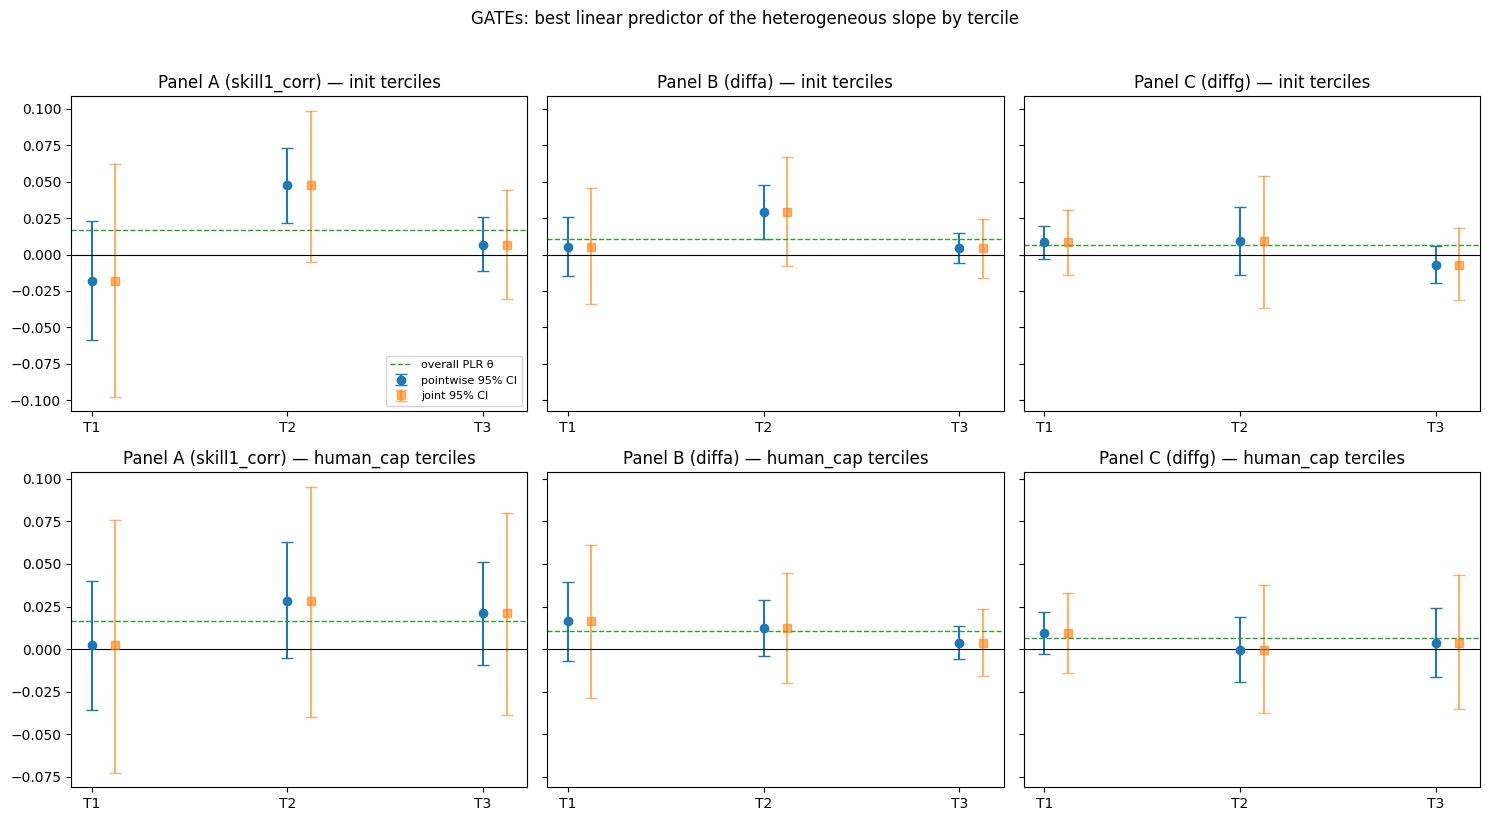

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey="row")
for j, (panel, pname) in enumerate([("A", "skill1_corr"), ("B", "diffa"),
                                    ("C", "diffg")]):
    for i, var in enumerate(["init", "human_cap"]):
        g = step4[panel][f"gate_{var}"]
        ax = axes[i, j]
        x = np.arange(len(g["groups"]))
        est = np.array(g["effect"])
        ax.errorbar(x, est,
                    yerr=[est - np.array(g["ci_lower"]),
                          np.array(g["ci_upper"]) - est],
                    fmt="o", capsize=4, label="pointwise 95% CI")
        ax.errorbar(x + 0.12, est,
                    yerr=[est - np.array(g["ci_joint_lower"]),
                          np.array(g["ci_joint_upper"]) - est],
                    fmt="s", capsize=4, alpha=0.6, label="joint 95% CI")
        ax.axhline(0, color="k", lw=0.8)
        full = step3[panel][f"{step4[panel]['learner']}_k2"]
        ax.axhline(full["coef"], color="tab:green", ls="--", lw=1,
                   label="overall PLR θ")
        ax.set_xticks(x, [t.split()[-1] for t in g["groups"]])
        ax.set_title(f"Panel {panel} ({pname}) — {var} terciles")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.suptitle("GATEs: best linear predictor of the heterogeneous slope by tercile",
             y=1.02)
fig.tight_layout()
fig.savefig(ROOT / "output" / "gate_terciles.png", dpi=150,
            bbox_inches="tight")
plt.show()

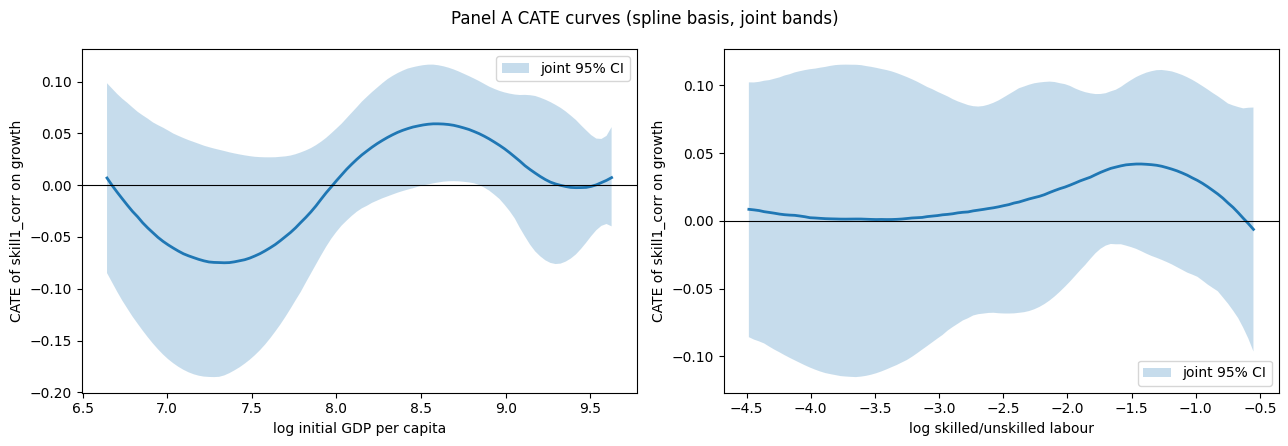

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
panel = "A"
for ax, var, label in [(axes[0], "init", "log initial GDP per capita"),
                       (axes[1], "human_cap", "log skilled/unskilled labour")]:
    c = step4[panel][f"cate_{var}"]
    grid = np.array(c["grid"])
    ax.plot(grid, c["effect"], lw=2)
    ax.fill_between(grid, c["ci_joint_lower"], c["ci_joint_upper"], alpha=0.25,
                    label="joint 95% CI")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel(label)
    ax.set_ylabel("CATE of skill1_corr on growth")
    ax.legend()
fig.suptitle("Panel A CATE curves (spline basis, joint bands)")
fig.tight_layout()
fig.savefig(ROOT / "output" / "cate_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
rows = []
for panel in ["A", "B", "C"]:
    for var in ["init", "human_cap"]:
        g = step4[panel][f"gate_{var}"]
        for i, grp in enumerate(g["groups"]):
            rows.append({"Panel": panel, "Moderator": var, "Group": grp,
                         "GATE": round(g["effect"][i], 4),
                         "95% CI": f"[{g['ci_lower'][i]:.4f}, {g['ci_upper'][i]:.4f}]",
                         "joint 95% CI": f"[{g['ci_joint_lower'][i]:.4f}, {g['ci_joint_upper'][i]:.4f}]"})
pd.DataFrame(rows).set_index(["Panel", "Moderator", "Group"])

GATE             95% CI       joint 95% CI
Panel Moderator Group                                                     
A     init      init T1      -0.0178  [-0.0584, 0.0227]  [-0.0978, 0.0620]
                init T2       0.0477   [0.0214, 0.0734]  [-0.0048, 0.0988]
                init T3       0.0068  [-0.0114, 0.0257]  [-0.0304, 0.0442]
      human_cap human_cap T1  0.0026  [-0.0358, 0.0400]  [-0.0727, 0.0757]
                human_cap T2  0.0285  [-0.0051, 0.0626]  [-0.0401, 0.0954]
                human_cap T3  0.0210  [-0.0092, 0.0509]  [-0.0389, 0.0802]
B     init      init T1       0.0055  [-0.0146, 0.0257]  [-0.0342, 0.0455]
                init T2       0.0293   [0.0109, 0.0480]  [-0.0077, 0.0670]
                init T3       0.0048  [-0.0056, 0.0147]  [-0.0159, 0.0247]
      human_cap human_cap T1  0.0163  [-0.0068, 0.0393]  [-0.0286, 0.0613]
                human_cap T2  0.0123  [-0.0042, 0.0287]  [-0.0202, 0.0445]
                human_cap T3  0.0039  [-0.0060, 0.0136]  [-0.0159, 0.0233]
C     init      init T1       0.0084  [-0.0028, 0.0197]  [-0.0137, 0.0305]
                init T2       0.0090  [-0.0141, 0.0324]  [-0.0365, 0.0542]
                init T3      -0.0069  [-0.0192, 0.0056]  [-0.0312, 0.0179]
      human_cap human_cap T1  0.0093  [-0.0028, 0.0216]  [-0.0142, 0.0329]
                human_cap T2 -0.0007  [-0.0192, 0.0190]  [-0.0374, 0.0376]
                human_cap T3  0.0038  [-0.0165, 0.0240]  [-0.0354, 0.0435]

**How to read this.** Each GATE is the average of the
best-linear-predictor of the heterogeneous slope within a tercile — with
n = 63 these are exploratory by construction. The joint bands are the
decision-relevant ones: a group is only "different" if the joint bands
separate. As with the average effect, heterogeneity here describes the
*partial association* under the inherited conditioning set.

## 8. Honest assessment

**What replicated exactly.** The original OLS Table 4 (cols 1, 2, 4):
coefficient-for-coefficient at printed precision, same n, same R².

**What replicated statistically.** B&N's headline qualitative finding — DML
with flexible nuisances roughly halves the tariff-skill-bias coefficient and
removes its 5%-level significance for most learners — emerges from our
independent reimplementation as well. Learner-level cells carry explicit
consistent/tension/divergent labels in the gap table; exact equality is not
attainable even in principle (B&N's own pipeline is not seed-reproducible,
and R/Python learner stacks differ in documented ways: `lambda.1se` vs
CV-minimum lasso, `rpart` vs sklearn pruning, `gbm` vs sklearn boosting
internals, `nnet` vs MLPRegressor optimizers).

**What has no benchmark.** B&N's causal-forest check for tariffs lives in
their online appendix (Table S3.5), which is not part of the published PDF
in our possession — so our GATE/CATE section is validated only in the weaker
sense that its *average* implied effect lines up with the Section 5
estimates. GATES/generic-ML comparison is not applicable to this study
(binary-treatment requirement) — saying so plainly is part of the result.

**Substantive caveats inherited from the original.** Conditional exogeneity
of tariff structure is not credible as a causal claim (the original authors
say as much); DML tightens functional form, not identification. PLR's θ is
an overlap-weighted average under heterogeneity. n = 63 makes all
heterogeneity exploratory.

**What this proves for RECAST.** The full chain — replicate exactly, extend
with DML under inherited controls, validate against an independent published
benchmark, report gaps honestly — is feasible end-to-end in Python on one
laptop. The pipeline-design consequences (decision rules, agent
decomposition, referee structure) are written up in `../PIPELINE_DESIGN.md`.